In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics

In [22]:
CarData = pd.read_csv('/content/CAR DETAILS FROM CAR DEKHO.csv')
CarData.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [23]:
CarData.shape

(4340, 8)

In [24]:
CarData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [25]:
CarData.isnull().sum().sum()

np.int64(0)

In [26]:
CarData.fuel.value_counts()

,count
fuel,
Diesel,2153
Petrol,2123
CNG,40
LPG,23
Electric,1




```
# Encoding
```



In [27]:
CarData.replace({'fuel':{'Petrol':0,'Diesel':1,'CNG':2,'LPG':3,'Electric':4}},inplace=True)
CarData.replace({'seller_type':{'Dealer':0,'Individual':1,'Trustmark Dealer':2}},inplace=True)
CarData.replace({'transmission':{'Manual':0,'Automatic':1}},inplace=True)

/tmp/ipykernel_1934/4153463410.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  CarData.replace({'fuel':{'Petrol':0,'Diesel':1,'CNG':2,'LPG':3,'Electric':4}},inplace=True)
/tmp/ipykernel_1934/4153463410.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  CarData.replace({'seller_type':{'Dealer':0,'Individual':1,'Trustmark Dealer':2}},inplace=True)
/tmp/ipykernel_1934/4153463410.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly cal

In [28]:
CarData.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,0,1,0,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,0,1,0,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,1,1,0,First Owner
3,Datsun RediGO T Option,2017,250000,46000,0,1,0,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,1,1,0,Second Owner


# Train test split

In [29]:
X = CarData.drop(['selling_price','name','owner'],axis=1)
Y = CarData['selling_price']

In [30]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.1, random_state=2)


# Linear Regration

In [31]:
Linear = LinearRegression()

prediction for training data

In [32]:
Linear.fit(X_train,Y_train)

LinearRegression()

In [33]:
Prediton = Linear.predict(X_train)

In [34]:
error_score = metrics.r2_score(Y_train, Prediton)
print("R squared error : ", error_score)

R squared error :  0.42707003860717474


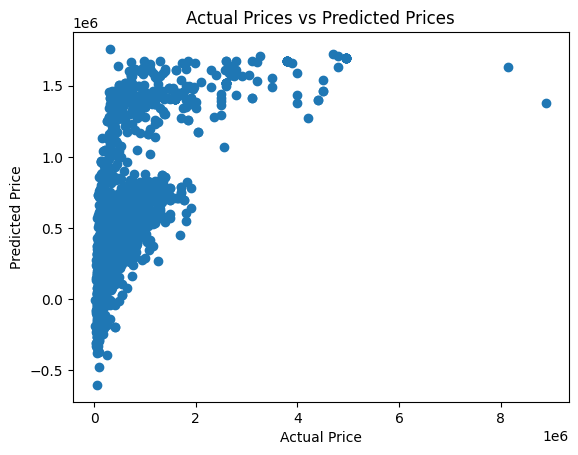

In [35]:
plt.scatter(Y_train, Prediton)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Prices vs Predicted Prices")
plt.show()

for testing data

In [36]:
Test_pred = Linear.predict(X_test)

In [37]:
error_score = metrics.r2_score(Y_test, Test_pred)
print("R squared error : ", error_score)

R squared error :  0.5035628808178241


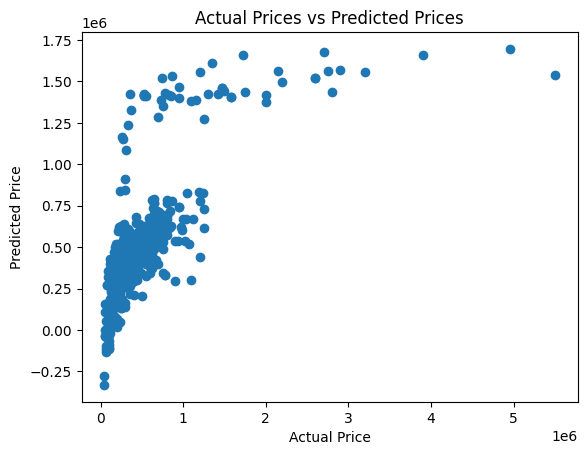

In [38]:
plt.scatter(Y_test, Test_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Prices vs Predicted Prices")
plt.show()

# 2) Lasso Regrassion

In [39]:
Lasso = Lasso()

In [41]:
Lasso.fit(X_train,Y_train)

Lasso()

In [45]:
Lasso_train_pred = Lasso.predict(X_train)

In [46]:
error_score = metrics.r2_score(Y_train, Lasso_train_pred)
print("R squared error : ", error_score)

R squared error :  0.4270700385568609


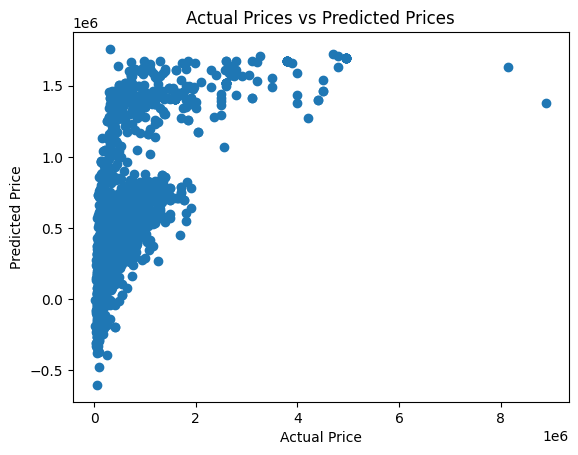

In [49]:
plt.scatter(Y_train, Lasso_train_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Prices vs Predicted Prices")
plt.show()

In [47]:
Lasso_test_pred = Lasso.predict(X_test)

In [48]:
error_score = metrics.r2_score(Y_test, Lasso_test_pred)
print("R squared error : ", error_score)

R squared error :  0.5035622748454045


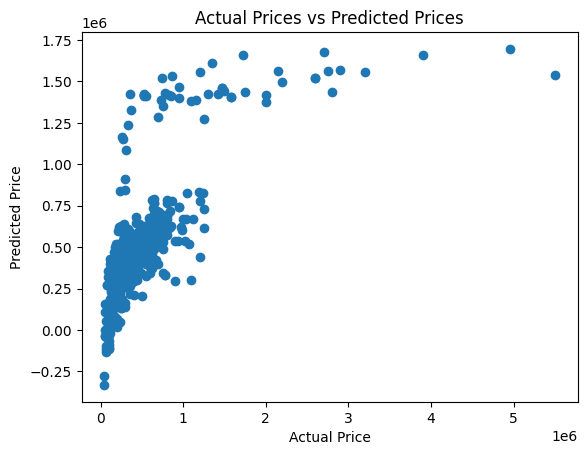

In [50]:
plt.scatter(Y_test, Lasso_test_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Prices vs Predicted Prices")
plt.show()